# Netrunner Agenda Points Analysis

In [1]:
# Imports

import pandas as pd
import main as m
import regex as re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import warnings
warnings.filterwarnings('ignore')

import notebook_companion as nc

## Wrangle

### Analysis Methodology

* Develop a possibility matrix for all legal combinations of minimum deck size, use of the four card margin, agenda point total, and distribution of 1, 2, and 3 point agendas for corporation decks
* Each feature is represented as a column in a dataframe and each row represents one unique combination of these features
* Add a additional rows to the matrix by replacing the maximum number of normal two-point agendas with Let Them Dream agendas 
* Calculate access threshold for each row using digital experiments
* Examine how different feature values shift the possibility matrix to determine the effect of those features on access threshold 

### Methodology of Digital Experiments to Determine Access Threshold

* Access threshold is the average number of unique random accesses a runner needs to steal 7 points worth of agendas and win the game
* The access threshold of each combination of features or row was calculated using the following method
    * Represent the corporation's deck by making a list containing a number of values equal to the testing deck’s deck size
        *  Values in the list represent the agenda point values of the agendas in the deck
            *  Mostly zeros with a number of one, two, and three values equal to the number of one, two, and three point agendas in the deck
    * Simulate a random access by choosing a value at random from the list and adding that value to the runners total score
    * Simulate the accessed card being stolen, trashed (discarded from play), or otherwise avoided by removing that card from the list
    * Continue simulating random accesses until the runner has a score of 7 or more and count the number of accesses it took to reach this total
    * To ensure a large sample size and reduce statistical error repeat the experiment 100,000 times and get the average result
    * Round result to the nearest whole number for ease of discussion and communicability of result

### Let Them Dream Methodology

* Let Them Dream is a two-point agenda with an ability that reduces its vale by 1 if it is in the runner's score area effectively making it a two-point agenda for the corporation and a one-point agenda for the runner
* To measure the impact of Let Them Dream agendas on access threshold additional rows were added to simulate replacing ‘normal’ two-point agendas with maximum allowable number of ‘Let Them Dream’ agendas
    * For each row with one or more two-point agendas an additional row was added replacing up to a maximum of three two-point agendas with Let Them Dream Agendas
    * A maximum of 3 replacements are made because the maximum number of card copies (by title) that can be included in a deck is 3
    * A replacement is simulated by lowering the number of two-point agendas by one and increasing the number of one-point agendas by one
    * This effectively counts the agenda as being worth 2 points for agenda point total and 1 point if the runner steals the agenda
    <br>
* **Limitation**
    * This matrix only includes possibilities replacing the maximum number normal two-point agendas
        * It does not account for replacing less than the maximum (Example has 2 two-point agendas but only replaces one)
        * It does not account for replacements swapping 2 one-point agendas for 1 Let Them Dream
        * It does now account for replacements swapping 1 three-point agenda for 1 one-point agenda and 1 Let Them Dream
        * This limitation is largely due to oversight and will be corrected if I should return to this project for future iterations

### Final Dataframe
* 8 columns and 928 total rows
    * Each column representing a feature of the deck
    * 496 rows representing all legal combinations of deck features
    * 432 rows that simulate replacing ‘normal’ two-point agendas with maximum allowable number of ‘Let Them Dream’ agendas

### Data Dictionary

|Feature|Definition|
|---|---|
|Deck Size| Count of cards in the deck|
|Agenda Points| Total value of all agenda points on agendas |
|Agenda Count| count of agendas |
|One-Point Agendas| Count of agendas with a value of 1 |
|Two-Point Agendas| Count of agendas with a value of 2 |
|Three-Point Agendas| Count of agendas with a value of 3 |
|LTD Count| Count of "Let Them Dream" agendas |
|Agenda Density| Agenda Points Divided by Deck Size |
|Access Threshold| Average number of unique cards a runner must access win the game |

In [2]:
# read in data
df, df_normal, df_ltd = nc.get_my_data()

## Data Exploration

### Overview of Access Threshold 

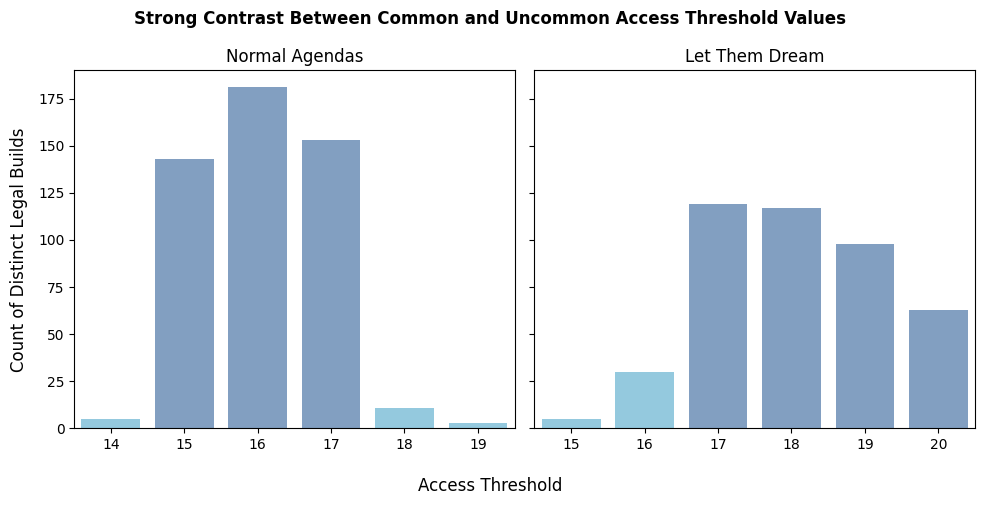

In [3]:
# get build count by access threshold chart
nc.get_my_thresholds(df_normal, df_ltd)

* The grand majority of normal agenda builds have an access threshold that ranges between 15 and 17 indicating that values outside the of majority range will only occur under precise conditions
* The grand majority of Let Them Dream builds have an access threshold between 17 and 20
indicating that values lower than the majority range will only occur under precise conditions
* The shift in majority range from 15-17 in normal builds to 17-20 in Let Them Dream builds indicates that replacing normal two-point agendas with Let Them Dream agendas could increase access threshold by 2-3 accesses

### What is the Effect of Agenda Density on Access Thereshold?
* In this study I define agenda density as the number of agenda points in a build relative to the total number of cards in that build
* I have calculated agenda density by dividing the number of agenda points in each build by the total number of cards in that build

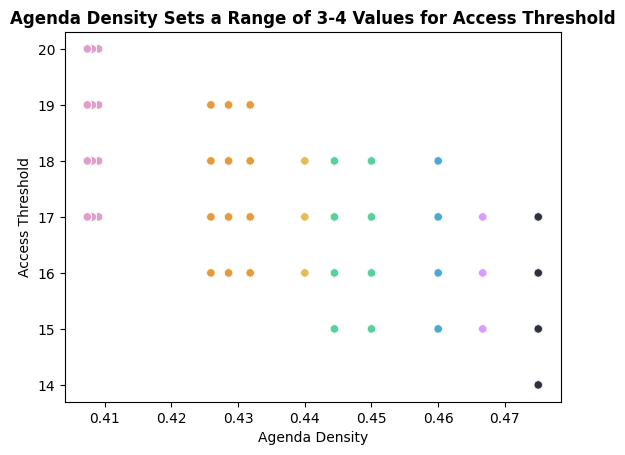

In [4]:
# get agenda density chart
nc.get_my_density_chart(df)

* Agenda density has a negative relationship with access threshold setting a range of 3-4 possible values

### What is the Effect of Deck Size on Access Threshold?

### Minimum Deck Size

* The minimun deck size for a corporation deck is 40, 45, or 50 depending on the identity card chosen for the build

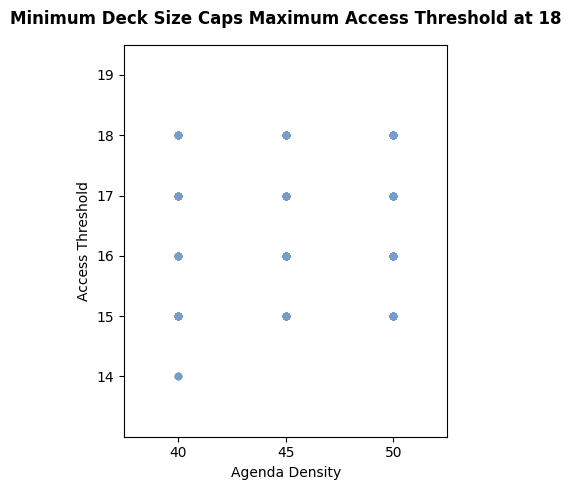

In [5]:
# get minimum deck size chart
nc.get_min_deck_chart(df)

* Decks using the minimum deck size have a maximum access threshold of 18
* There is a negligible difference in access threshold between minimum deck sizes
    * The possibility of a particularly low access threshold does exist when using a 40 card build

### 4 Card Margin
* Corporation decks are required to include a number of agenda points based on total number of cards in the deck
* The agenda point requirement increases with every 5th card added
* For that reason it is conventional wisdom to build corporation decks 4 cards over the minimum to reduce agenda density
* I call this the 4 card margin

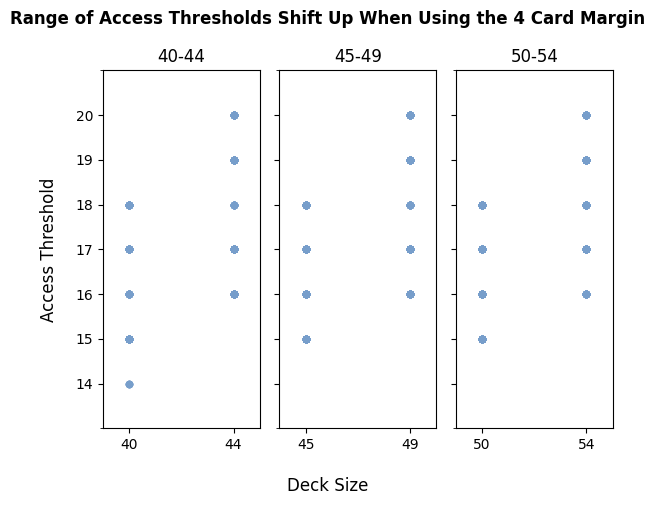

In [6]:
# get 4 card margin chart
nc.get_margin_chart(df)

* Based on the shift in the access threshold range using the four card margin will raise a build's access threshold by 1-2 accesses

## What is the Effect of Agenda Point Total on Access Threshold?

* Corporation decks are required to include a number of agenda points based on total number of cards in the deck and can include one extra agenda point if desiered
* It is conventional wisdom to include only the minimum number of agenda points to reduce agenda density

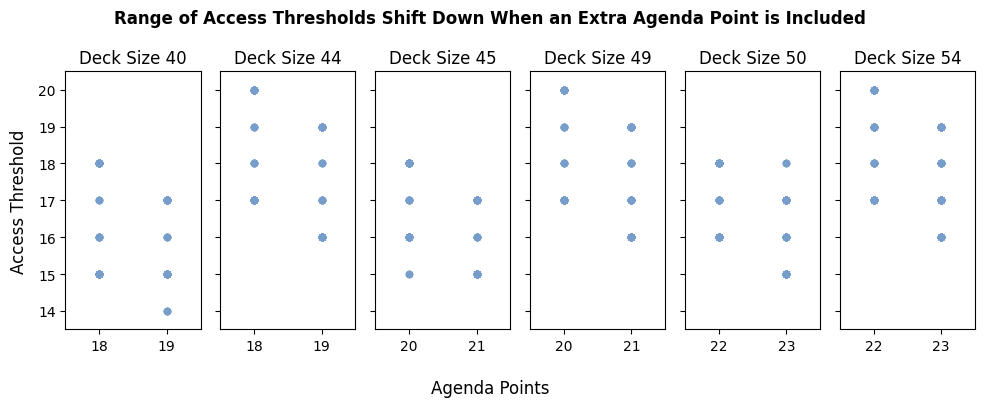

In [7]:
# get agenda point chart
nc.get_my_min_agenda_chart(df)

* The shift in the access threshold range indicates that builds using the minimum number of agenda points have an access threshold that is about 1 access higher than builds that include an extra agenda point

## Agenda Density Summary

**Overall Agenda Density**
* Agenda density has a negative relationship with access threshold setting a range of 3-4 possible values

**Deck Size**
* Decks using the minimum deck size have a maximum access threshold of 18
* Minimum deck size has negligible impact on Access threshold
* Use of the 4 card margin will increase access threshold by about 1-2 accesses

**Agenda Points**
* Builds using the minimum number of agenda points have an access threshold that is about 1 access higher than builds that include an extra agenda point

## Agenda Concentration

* In this study I define agenda concentration as the degree to which agenda points are concentrated in high point cards or spread out in lower point cards
    * For example a deck with one three-point agenda has a higher concentration of agenda points that a deck with three one-point agendas even though the total number of agenda points is the same

**Looking at Normal Agendas**
* The deck-building flexibility given by Let Them Dream's ability to modify its agenda values creates too much noise in the possibility matrix to get a clear signal
* In this section we will be looking at builds that do not include Let Them Dream

### What is the Effect of Agenda Count on Access Threshold?

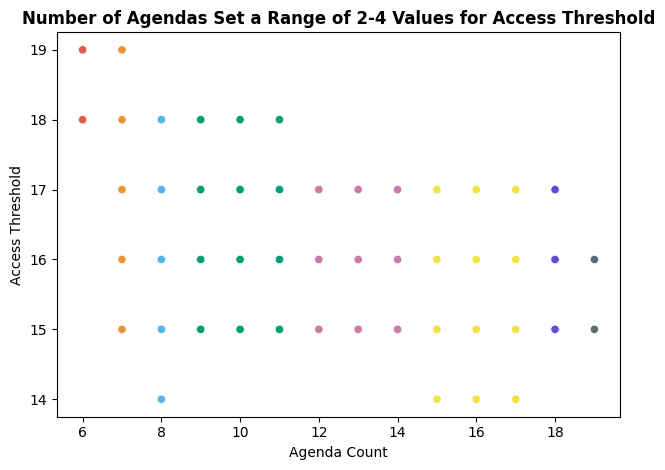

In [8]:
# get agenda count chart
nc.get_my_agenda_count_chart(df_normal)

* There is a negative relationship between agenda count and access threshold setting a range of 2-4 possible values 

### What is the Effect of Three-Point Agenda Count on Agenda Threshold?

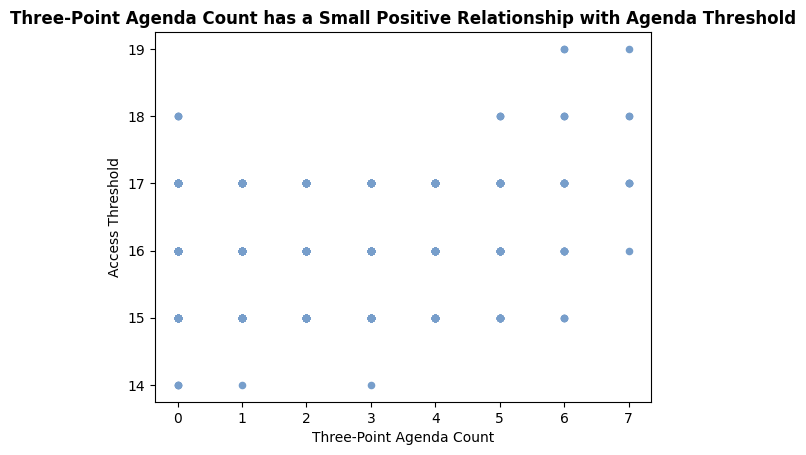

In [9]:
# get three point agenda chart
nc.get_my_threes_chart(df_normal)

* There is a small positive relationship between three-point agenda count and access threshold

#### Outlier Builds

* The builds with zero three-point agendas and an access threshold of 18 stood out as outliers

In [10]:
# get example dataframe
df_example = nc.get_my_first_outlier_df(df_normal)
df_example

,deck_size,agenda_points,three_point_agendas,two_point_agendas,one_point_agendas,access_threshold
186,44,18,0,9,0,18
501,49,20,0,10,0,18
858,54,22,0,11,0,18


* All of these builds used the 4 card margin, lowest agenda point total, and had only two-point agendas (the lowest possible agenda density and concentration outside of using three-point agendas)
* Stacking these other advantages gave an above average access threshold while not using three-point agendas

### What is the Effect of One-Point Agenda Count on Agenda Threshold?

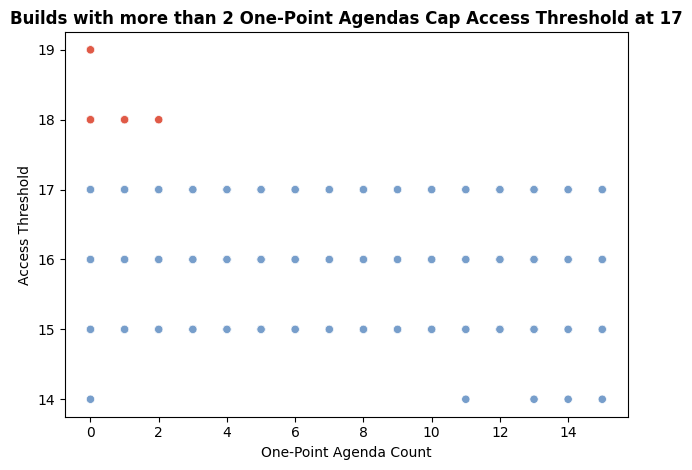

In [11]:
# get one point agenda chart
nc.get_my_ones_chart(df_normal)

* There is a small negative relationship between one-point agenda count and access threshold
* Builds containing 3 or more one-point agendas cannot have an access threshold higher than 17

**Outlier Builds**
* The build with 0 one-point agendas and an access threshold of 14 stood out as an outlier
* There is only one possible build that meets this criteria

In [12]:
nc.get_my_second_outlier_df(df)

,agenda_type,deck_size,agenda_points,one_point_agendas,two_point_agendas,three_point_agendas,access_threshold
135,Normal,40,19,0,5,3,14


* This build contains the minimum possible deck size and uses the highest agenda point total for its deck size, giving is the highest possible agenda density in the game explaining its low access threshold


## Agenda Concentration Summary
* Agenda Count has a negative relationship with access threshold setting a range of 2-4 possible values 
* Three-point agenda count has a small positive relationship with access threshold
* One-point agenda count has a small negative relationship with access threshold

## What is the Effect of Let Them Dream Agendas on Access Threshold?

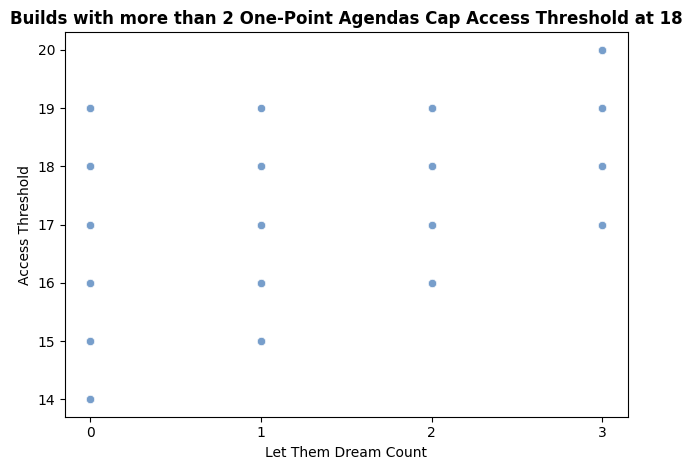

In [13]:
nc.get_my_ltd_data(df)

* The shift in access threshold range indicates that replacing normal two-point agendas with Let Them Dream agendas increse access threshold by about 1 access per replacement

## Full Summary

**General**
* Access thresholds across all possible builds have a range of 14 to 20 meaning that deck building decisions have a 6 access influence on access threshold
* Agenda density has a negative relationship on access threshold
* Builds with a higher concentration of agenda points have higher access thresholds
* Agenda density has a stronger effect on acces threshold than agenda concentration
  
**Agenda Density**
* Minimum deck size has a negligible effect on access threshold
* Using the 4 card margin increases access threshold by about 1-2 accesses
* Builds using the minimum agenda point total have an access threshold of about 1 access higher than build including an extra agenda point   

**Agenda Concentration**
* There is a negative relitionship between agenda count and access threshold setting a range of 2-4 possible values
* There is a small positive relationship between three-point agenda count and access threshold
* There is a small negative relationship between one-point agenda count and a access threshold

**Let Them Dream**
* Replacing normal 2-point agendas with Let Them Dream agendas will increase access threshold by about 1 access per replacemnet 

## Recommendations

**Access threshold is a factor to be considered when optimizing a build rather than being the main focus of a build**
* Access threshold has a range of 7 accesses that are determined through deck building decisions with most normal builds falling between  15 and 17 meaning that the impact of optimizing for access threshold has its limits
* A higher access threshold will help you edge out victories in games with compeditive board states, however making the runner access a few extra cards is unlikely to turn the tide if your boardstate is poor

**Rely on conventional wisdom when optimizing for access threshold**
* Using the 4 card margin will increase your access threshold by 1-2 accesses while granting you additional resources, in the form of the 4 added cards, at the cost of slightly reduced concistancy due to the increased deck size
    * A good choice for most if not all builds 
* Using the minimum number of agenda points will increase your access threshold by about 1 access compared to builds that include an extra agenda point
    * A good choice for most if not all builds 
* Using high value agenda cards instead of low value agenda cards will increase your access threshold by a small amount
    *  The impact of agenda density is limited however if you find that multiple agenda cards synergize just as well in your deck prioritise agendas with higher values
 
**Strongly consider including Let Them Dream in your build**
* Replacing normal 2-point agendas with Let Them Dream agendas will increase access threshold by about 1 access per replacemnet
    * Effectively it lowers the number of agenda points available for the runner to steal by 1 per inclusion
    * Its ability also allowing you to shuffle away agendas from HQ and 'hide' high point agendas on the bottom of R&D after scoring it further reducing the odds of the runner stealing agenda during a blind access
* There are reasons not to include Let Them Dream in your build 
    * The card is neutral cost 1 influence per copy in any deck it is included in
    * It compeats for deck slots with other agendas that might provide more synergy